In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import os
import pickle
import gzip
import io
import tempfile
import h5py
import bz2
import pyreadr
import json

In [2]:
from _utils._utils_spline import eval_spline_basis_equispaced_numeric
from _utils._utils_models import builder_dict

Failed Data


# active_3YR.h5.gz

In [3]:
data_path3 = os.path.join('../data/', 'youtube/active_3YR.h5.gz')

In [4]:
with gzip.open(data_path3, "rb") as f:
    with tempfile.NamedTemporaryFile(suffix=".h5") as tmp:
        tmp.write(f.read())
        tmp.flush()

        with pd.HDFStore(tmp.name, mode="r") as store:
            df3 = store["df"]

In [5]:
df3.head(2)

,id,channelId,channelName,views,shares,categoryName,publishedTime
0,vnzCcY8h-2o,UC5zJwsFtEs9WYe3A76p7xIA,Professor Live,"[137674, 85416, 16669, 8044, 4316, 2825, 3894,...","[201, 118, 33, 19, 14, 4, 6, 6, 2, 3, 3, 2, 9,...",Entertainment,2017-07-06T22:00:03.000Z
1,mOCtff_INtk,UC5zJwsFtEs9WYe3A76p7xIA,Professor Live,"[103108, 106505, 10651, 5472, 6334, 3853, 2723...","[49, 39, 8, 4, 2, 4, 0, 0, 0, 0, 0, 2, 2, 1, 0...",Entertainment,2017-06-07T23:13:41.000Z


# active-dataset.dat

In [6]:
data_path14 = os.path.join('../data/', 'youtube/active-dataset.json.bz2')

In [7]:
with bz2.open(data_path14, "rb") as f:
    raw = f.read()

text = raw.decode("utf-8", errors="replace")
data = json.loads(text)
df14 = pd.DataFrame(data)

In [8]:
df14.head(2)

,YoutubeID,numTweet,numShare,numSubscriber,watchTime,dailyViewcount,description,title,channelId,channelTitle,...,dimension,caption,regionRestriction.blocked,regionRestriction.allowed,topicIds,relevantTopicIds,totalShare,totalViewcount,totalTweet,dailyTweets
0,00-6OyXVA0M,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[254, 1399, 493, 242, 175, 216, 372, 729, 305,...","[4, 19, 19, 7, 2, 5, 8, 17, 6, 3, 2, 1, 3, 1, ...","[59311.9833333, 455426.75, 206253.816667, 1119...","[90158, 695628, 312298, 170348, 82346, 61530, ...",Bill's response to Victoria Osteen's congregat...,Bill Cosby responds to Victoria Osteen,UCpzGw-b-rEPjRs2LT0ZVHTQ,Bryant Harris,...,2d,false,{},{},"[/m/03bxbhz, /m/03ny9x, /m/014zfs]",[/m/06bvp],5206,2174286,3857,"[2588, 455, 157, 100, 86, 76, 102, 64, 28, 23,..."
1,00ATf2HR-FA,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[12, 47, 14, 32, 32, 12, 5, 4, 3, 4, 1, 0, 3, ...","[2, 2, 0, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...","[2937.13333333, 9039.33333333, 5082.71666667, ...","[14939, 40664, 21261, 30914, 31073, 20395, 117...",Adorable Cute South Korean Dog Gets Neck Massa...,Adorable Cute South Korean Dog Gets Neck Massage,UCT7HvytJiHm4BITiIQU1zwg,CloudSheep,...,2d,false,{},{},"[/m/0b_nd, /m/0bt9lr]",[/m/04h3kx],201,227149,189,"[75, 25, 18, 18, 15, 5, 10, 2, 0, 1, 2, 0, 1, ..."


---

In [14]:
regional_geocode_to_range = {
    31003: (630, 745),
    43028: (432, 591),
    52003: (200, 400),
    29003: (380, 746),
}
regional_geocode = 29003
time_range = regional_geocode_to_range[regional_geocode]

In [15]:
select_df = dengue_data[(dengue_data['regional_geocode'] == regional_geocode) & (dengue_data['t'] >= time_range[0]) & (dengue_data['t'] <= time_range[1])]
select_df = select_df.groupby(['regional_geocode', 't'], as_index=False)['casos'].sum()

In [16]:
degree = 3
x_vals = select_df['t'].values
x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 1000)
num_knots = 5
B_plot = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot)['B']
n, k = B_plot.shape
B_1 = B_plot[:, -1].reshape(-1, 1)
B_1 = B_1/(np.max(B_1) - np.min(B_1))*(np.max(select_df['casos']) - np.min(select_df['casos']))

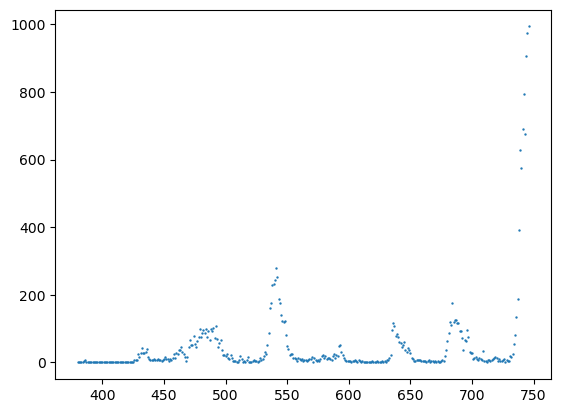

In [18]:
plt.scatter(select_df['t'], select_df['casos'], s=0.5)
#plt.plot(x_plot, B_1, lw=0.5)
plt.show()

In [89]:
f = f'dengue_{regional_geocode}_{time_range[0]}_{time_range[1]}_k{num_knots}'
sigma = 0.5
r = [0]

data_pickle = {(f, sigma):{0:(select_df['t'].values, select_df['casos'].values)}}

In [90]:
dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

---

In [ ]:
macroregional_geocode = 4217
time_range = (400, 650)

macroregional_geocode = 3521
time_range = (440, 745)

In [31]:
select_df = dengue_data[(dengue_data['macroregional_geocode'] == macroregional_geocode) & (dengue_data['t'] >= time_range[0]) & (dengue_data['t'] <= time_range[1])]

In [36]:
degree = 3
x_vals = select_df['t'].values
x_plot = np.linspace(np.min(x_vals), np.max(x_vals), 100)
num_knots = 20
B_plot = eval_spline_basis_equispaced_numeric(degree, np.min(x_vals), np.max(x_vals), num_knots, x_plot)['B']
n, k = B_plot.shape
B_1 = B_plot[:, -1].reshape(-1, 1)
B_1 = B_1/(np.max(B_1) - np.min(B_1))

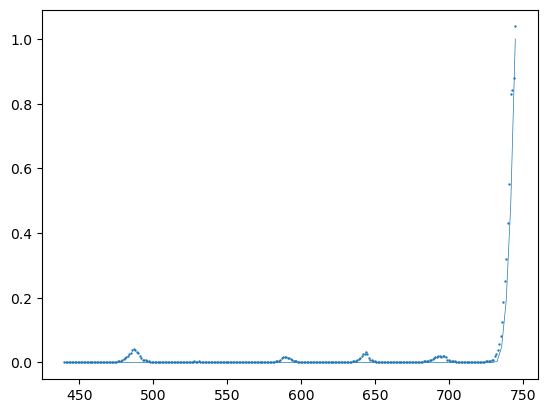

In [37]:
plt.scatter(select_df['t'], select_df['casos']/50000, s=0.5)
plt.plot(x_plot, B_1, lw=0.5)
plt.show()

In [10]:
f = 'dengue_3521_440_745_k20_s'
sigma = 0.5
r = [0]

data_pickle = {(f, sigma):{0:(select_df['t'].values, select_df['casos'].values//50)}}

In [11]:
dengue_data_path = os.path.join("../data", f"{f}.pkl")
if True:
    with open(dengue_data_path, "wb") as f:
        pickle.dump(data_pickle, f)
with open(dengue_data_path, "rb") as f:
    data_dict = pickle.load(f)

In [75]:
print(dengue_data_path)

../data/dengue_3521_440_745_k20.pkl
